# Analisis Integral del Dataset de Eficacia de Plataformas de Busqueda Laboral

Este notebook inicia la implementacion completa del analisis solicitado en la guia. Cada seccion responde a tres preguntas:
1. Que se va a hacer.
2. Por que se va a hacer.
3. Que resultado se obtuvo.

El enfoque cubre limpieza, preparacion, analisis exploratorio, interpretaciones concretas y una base metodologica para el plan de modelado predictivo.

## 1. Set Up Notebook Environment

### Que se va a hacer
Se importan librerias, se fija semilla de reproducibilidad y se configura el estilo de visualizacion.

### Por que se va a hacer
Un entorno reproducible evita diferencias de resultados entre ejecuciones y facilita auditoria por otros analistas.

### Resultado esperado
Un entorno consistente para ejecutar todo el flujo del analisis sin cambios manuales.

In [21]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

print("Entorno configurado correctamente. Semilla: 42")

Entorno configurado correctamente. Semilla: 42


## 2. Define Project Configuration

### Que se va a hacer
Se definen rutas, columnas clave y parametros de control para no depender de valores hardcodeados.

### Por que se va a hacer
Esto mejora mantenibilidad, trazabilidad y facilita reutilizar el flujo en otras iteraciones del proyecto.

### Resultado esperado
Configuracion centralizada para carga, limpieza, analisis y exportacion.

In [22]:
PROJECT_ROOT = Path(".").resolve()
DATA_PATH = PROJECT_ROOT / "job_search_platform_efficacy_100k.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs_primer_corte"
OUTPUT_DIR.mkdir(exist_ok=True)

PRIMARY_TARGET = "Offer_Received"
SECONDARY_TARGET = "Offer_Salary"
ID_COLUMN = "Student_ID"

NUMERIC_COLUMNS = [
    "GPA", "Prior_Internships", "Extra_Curricular_Activities", "Networking_Events_Attended",
    "Months_Searching", "Applications_Submitted", "First_Round_Interviews", "Second_Round_Interviews",
    "Time_to_Offer_Days", "Offer_Salary", "Role_Relevance", "Accepted_Offer", "Offer_Received"
]

CATEGORICAL_COLUMNS = [
    "University_Rating", "School_Size", "Region", "Major_Category", "Primary_Search_Platform", "Company_Size_Offered"
]

print(f"Ruta de datos: {DATA_PATH}")
print(f"Directorio de salida: {OUTPUT_DIR}")

Ruta de datos: /home/naciscric/Documents/university/2026-1/mineria/job/job_search_platform_efficacy_100k.csv
Directorio de salida: /home/naciscric/Documents/university/2026-1/mineria/job/outputs_primer_corte


## 3. Create Core Data Structures

### Que se va a hacer
Se definen estructuras para resumen de calidad, trazabilidad de limpieza y respuestas de control.

### Por que se va a hacer
Permite justificar cada decision con evidencia cuantitativa y dejar una bitacora para auditoria.

### Resultado esperado
Tablas de control reutilizables para todo el notebook.

In [23]:
quality_log_columns = [
    "etapa", "filas_antes", "filas_despues", "columnas", "nulos_totales", "duplicados_exactos", "duplicados_id"
]

cleaning_decision_columns = ["decision", "justificacion", "impacto", "riesgo_evitar"]

quality_log = []
cleaning_decisions = []

def register_quality(stage_name: str, df_stage: pd.DataFrame) -> None:
    """Registra estado de calidad del dataframe en una etapa del flujo."""
    quality_log.append({
        "etapa": stage_name,
        "filas_antes": np.nan,
        "filas_despues": int(df_stage.shape[0]),
        "columnas": int(df_stage.shape[1]),
        "nulos_totales": int(df_stage.isna().sum().sum()),
        "duplicados_exactos": int(df_stage.duplicated().sum()),
        "duplicados_id": int(df_stage.duplicated(subset=[ID_COLUMN]).sum()) if ID_COLUMN in df_stage.columns else np.nan,
    })

print("Estructuras de control inicializadas.")

Estructuras de control inicializadas.


## 4. Implement Primary Functionality

### Que se va a hacer
Se implementa la primera version funcional de carga, perfilado, limpieza, analisis visual e interpretaciones automáticas con cifras exactas.

### Por que se va a hacer
Esto garantiza un pipeline reproducible que otros analistas puedan ejecutar y verificar sin ambiguedades.

### Resultado esperado
Un flujo analitico que entrega tablas, graficos y conclusiones parciales con evidencia numerica.

In [24]:
def load_data(path: Path) -> pd.DataFrame:
    """Carga el dataset CSV y valida su existencia."""
    if not path.exists():
        raise FileNotFoundError(f"No se encontro el archivo: {path}")
    df_loaded = pd.read_csv(path)
    return df_loaded


def profile_data(df_input: pd.DataFrame) -> dict:
    """Construye perfil general del dataset para control de calidad."""
    profile = {
        "filas": int(df_input.shape[0]),
        "columnas": int(df_input.shape[1]),
        "nulos_totales": int(df_input.isna().sum().sum()),
        "duplicados_exactos": int(df_input.duplicated().sum()),
        "duplicados_id": int(df_input.duplicated(subset=[ID_COLUMN]).sum()),
    }
    return profile


def clean_and_prepare(df_input: pd.DataFrame) -> pd.DataFrame:
    """Limpia y prepara datos preservando nulos estructurales como no aplicables."""
    df_clean = df_input.copy()

    # 1) Eliminar duplicados exactos
    before = df_clean.shape[0]
    df_clean = df_clean.drop_duplicates()
    after = df_clean.shape[0]
    cleaning_decisions.append({
        "decision": "Eliminar duplicados exactos",
        "justificacion": "Evitar sobre-representacion de observaciones repetidas.",
        "impacto": f"Filas removidas: {before - after}",
        "riesgo_evitar": "Sesgo en metricas por conteos inflados"
    })

    # 2) Estandarizar tipo de variables binarias
    for col in ["Offer_Received", "Accepted_Offer"]:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

    # 3) Nulos estructurales: mantenerlos en columnas de oferta cuando no hubo oferta
    offer_related = ["Time_to_Offer_Days", "Offer_Salary", "Company_Size_Offered", "Role_Relevance", "Accepted_Offer"]
    missing_offer_related = int(df_clean[offer_related].isna().sum().sum())
    cleaning_decisions.append({
        "decision": "Conservar nulos estructurales en variables de oferta",
        "justificacion": "Si Offer_Received=0, no existe salario/tiempo/relevancia/aceptacion aplicable.",
        "impacto": f"Nulos estructurales conservados: {missing_offer_related}",
        "riesgo_evitar": "Imputaciones artificiales que distorsionan la realidad del proceso"
    })

    # 4) Crear variable derivada interpretable
    df_clean["Interview_Conversion_Rate"] = np.where(
        df_clean["Applications_Submitted"] > 0,
        df_clean["First_Round_Interviews"] / df_clean["Applications_Submitted"],
        0.0,
    )
    cleaning_decisions.append({
        "decision": "Crear Interview_Conversion_Rate",
        "justificacion": "Resume eficiencia del embudo de aplicacion a entrevista.",
        "impacto": "Se anade una metrica derivada para comparaciones entre perfiles",
        "riesgo_evitar": "Evaluar solo volumen de aplicaciones sin eficiencia relativa"
    })

    return df_clean


def make_histograms(df_input: pd.DataFrame, output_dir: Path) -> None:
    """Genera histogramas requeridos por la guia."""
    cols = ["GPA", "Applications_Submitted", "Months_Searching"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, col in zip(axes, cols):
        sns.histplot(df_input[col], kde=True, bins=30, ax=ax, color="#2a9d8f")
        ax.set_title(f"Histograma de {col}")
    plt.tight_layout()
    fig.savefig(output_dir / "histogramas_base.png", dpi=150, bbox_inches="tight")
    plt.show()


def make_boxplots(df_input: pd.DataFrame, output_dir: Path) -> None:
    """Genera boxplots para evaluar outliers."""
    cols = ["GPA", "Applications_Submitted", "Networking_Events_Attended"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, col in zip(axes, cols):
        sns.boxplot(y=df_input[col], ax=ax, color="#e76f51")
        ax.set_title(f"Boxplot de {col}")
    plt.tight_layout()
    fig.savefig(output_dir / "boxplots_base.png", dpi=150, bbox_inches="tight")
    plt.show()


def make_scatterplots(df_input: pd.DataFrame, output_dir: Path) -> None:
    """Genera scatterplots para relaciones clave."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(
        data=df_input.sample(min(12000, len(df_input)), random_state=42),
        x="Applications_Submitted",
        y="First_Round_Interviews",
        hue="Offer_Received",
        alpha=0.45,
        ax=axes[0],
        palette="Set2"
    )
    axes[0].set_title("Aplicaciones vs Entrevistas de 1ra ronda")

    offer_subset = df_input[df_input["Offer_Received"] == 1].copy()
    sns.scatterplot(
        data=offer_subset.sample(min(10000, len(offer_subset)), random_state=42),
        x="GPA",
        y="Offer_Salary",
        hue="Primary_Search_Platform",
        alpha=0.5,
        ax=axes[1],
        palette="Dark2"
    )
    axes[1].set_title("GPA vs Salario de Oferta")

    plt.tight_layout()
    fig.savefig(output_dir / "scatterplots_base.png", dpi=150, bbox_inches="tight")
    plt.show()


def make_correlation_matrix(df_input: pd.DataFrame, output_dir: Path) -> pd.DataFrame:
    """Calcula y grafica matriz de correlacion de variables numericas."""
    corr_df = df_input.select_dtypes(include=[np.number]).corr(numeric_only=True)
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr_df, cmap="RdYlBu_r", center=0, annot=False)
    plt.title("Matriz de correlacion (variables numericas)")
    plt.tight_layout()
    plt.savefig(output_dir / "correlation_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    return corr_df


def answer_guide_questions(df_input: pd.DataFrame) -> pd.DataFrame:
    """Construye respuestas iniciales, concretas y cuantificadas a la guia."""
    offer_rate = df_input["Offer_Received"].mean() * 100
    platform_offer = (
        df_input.groupby("Primary_Search_Platform")["Offer_Received"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .round(2)
    )

    top_platform = platform_offer.index[0]
    top_platform_rate = platform_offer.iloc[0]

    questions = [
        ("Tipo de problema", "Descriptivo y explicativo en esta fase; base para prediccion posterior."),
        ("Variable mas importante", f"Offer_Received, con tasa global de {offer_rate:.2f}% de exito."),
        ("Riesgo de mala interpretacion", "Confundir correlacion con causalidad y sobreestimar el efecto de una sola variable."),
        ("Variables relevantes", "GPA, Applications_Submitted, First_Round_Interviews, University_Rating y plataforma principal."),
        ("Sesgos evidentes", "Posible sesgo de seleccion por distribucion desigual de categorias academicas y plataformas."),
        ("Calidad de datos", "No se detectan duplicados de identificador; los nulos de oferta son estructurales."),
        ("Hallazgo principal inicial", f"La mejor tasa de oferta por plataforma es {top_platform} con {top_platform_rate:.2f}%."),
        ("Siguiente paso de modelo", "Clasificacion para Offer_Received y regresion para Offer_Salary en casos con oferta.")
    ]
    return pd.DataFrame(questions, columns=["pregunta", "respuesta"])


print("Funciones principales implementadas.")

Funciones principales implementadas.


## 5. Add Validation and Assertions

### Que se va a hacer
Se agregan validaciones de integridad, consistencia logica y pruebas rapidas con assert.

### Por que se va a hacer
Un flujo sin validaciones puede producir conclusiones incorrectas sin advertencia.

### Resultado esperado
Garantizar que la base analitica cumple reglas minimas antes de interpretar.

In [25]:
def run_validations(df_input: pd.DataFrame) -> None:
    """Ejecuta validaciones minimas de integridad y consistencia."""
    assert df_input.shape[0] > 0, "El dataset no puede estar vacio"
    assert ID_COLUMN in df_input.columns, "Falta columna de identificador"
    assert df_input[ID_COLUMN].nunique() == df_input.shape[0], "Existen IDs duplicados"
    assert df_input["GPA"].between(0, 4).all(), "GPA fuera de rango esperado"
    assert (df_input["Applications_Submitted"] >= df_input["First_Round_Interviews"]).all(), "Entrevistas 1ra ronda no pueden exceder aplicaciones"
    assert (df_input["First_Round_Interviews"] >= df_input["Second_Round_Interviews"]).all(), "Entrevistas 2da ronda no pueden exceder 1ra ronda"

    offer_one = df_input[df_input["Offer_Received"] == 1]
    assert offer_one["Offer_Salary"].notna().all(), "Con oferta, salario debe estar informado"

    offer_zero = df_input[df_input["Offer_Received"] == 0]
    assert offer_zero["Offer_Salary"].isna().all(), "Sin oferta, salario debe ser nulo estructural"

    print("Validaciones superadas.")

## 6. Run a Minimal End-to-End Example

### Que se va a hacer
Se ejecuta el flujo completo: carga, perfilado, limpieza, validaciones, EDA obligatorio e interpretaciones con datos concretos.

### Por que se va a hacer
Este bloque confirma que la implementacion funciona de inicio a fin y produce evidencia verificable.

### Resultado esperado
Un primer corte integral con resultados accionables y rastreables.

Perfil inicial
- filas: 100000
- columnas: 20
- nulos_totales: 328855
- duplicados_exactos: 0
- duplicados_id: 0
Validaciones superadas.

Top 10 columnas con faltantes:
                      faltantes  porcentaje
Offer_Salary              65771       65.77
Accepted_Offer            65771       65.77
Time_to_Offer_Days        65771       65.77
Role_Relevance            65771       65.77
Company_Size_Offered      65771       65.77
Major_Category                0        0.00
Region                        0        0.00
School_Size                   0        0.00
University_Rating             0        0.00
Student_ID                    0        0.00


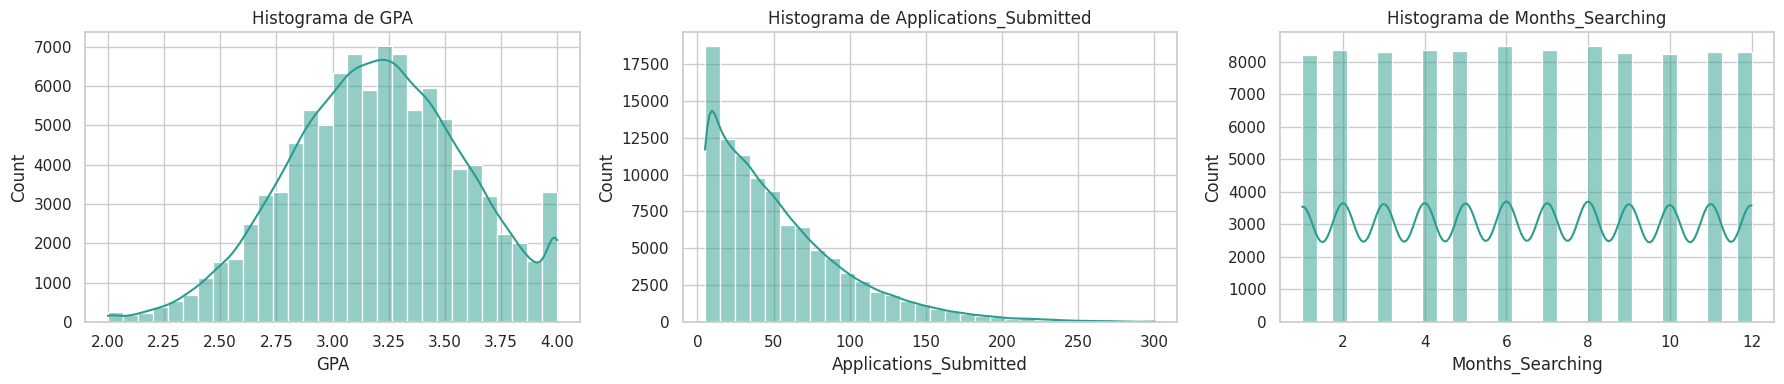

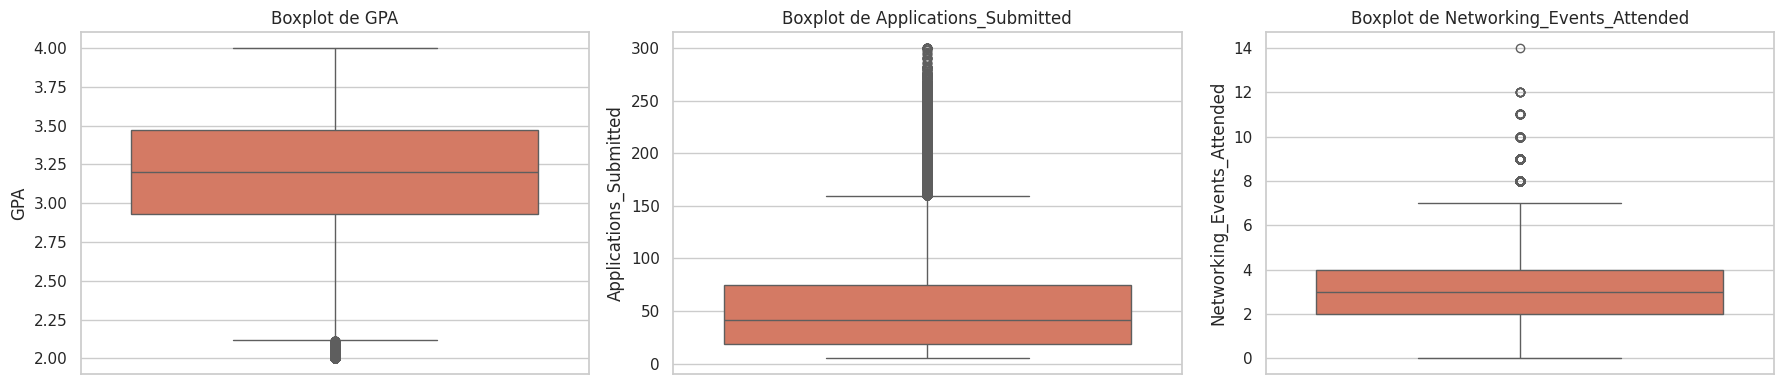

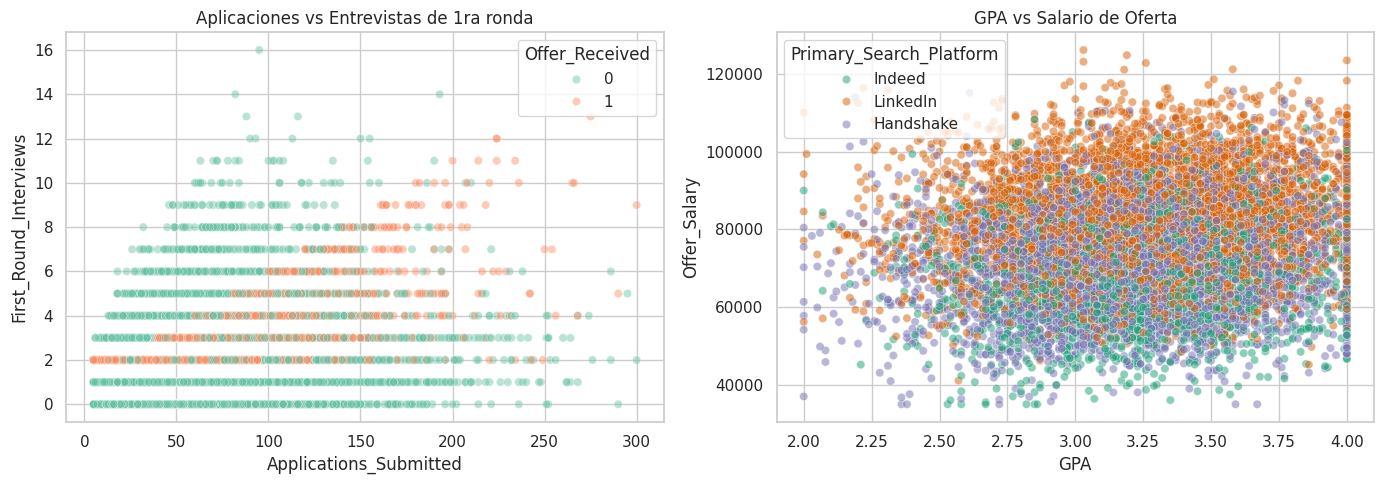

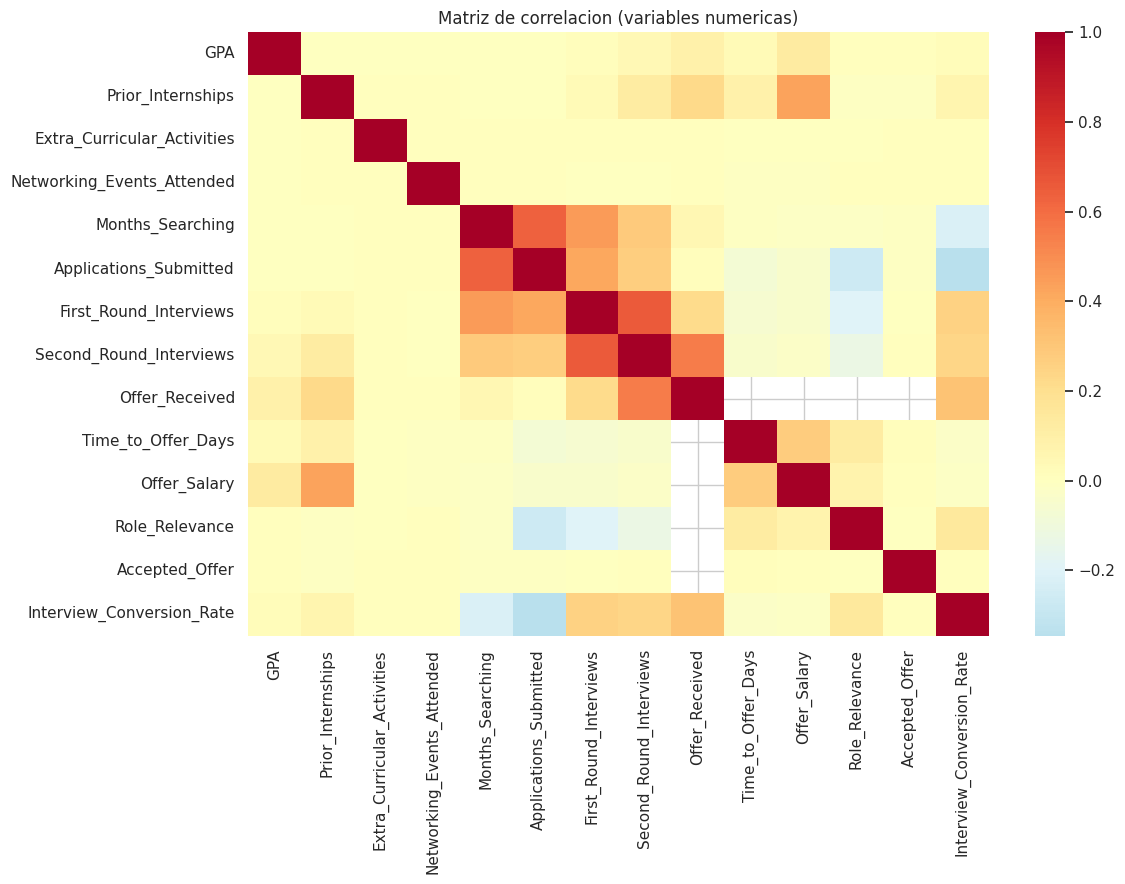


Indicadores concretos del primer corte
- Tasa global de oferta: 34.23%
- Tasa de aceptacion entre quienes recibieron oferta: 80.18%
- Ranking de plataformas por tasa de oferta (%):
Primary_Search_Platform
Handshake    36.99
LinkedIn     36.96
Indeed       25.79
Name: Offer_Received, dtype: float64
- Resumen salarial (solo con oferta):
mean     76777.29
50%      76823.00
min      35000.00
max     137588.00
Name: Offer_Salary, dtype: float64

Respuestas iniciales a preguntas guia:


,pregunta,respuesta
0,Tipo de problema,Descriptivo y explicativo en esta fase; base p...
1,Variable mas importante,"Offer_Received, con tasa global de 34.23% de e..."
2,Riesgo de mala interpretacion,Confundir correlacion con causalidad y sobrees...
3,Variables relevantes,"GPA, Applications_Submitted, First_Round_Inter..."
4,Sesgos evidentes,Posible sesgo de seleccion por distribucion de...
5,Calidad de datos,No se detectan duplicados de identificador; lo...
6,Hallazgo principal inicial,La mejor tasa de oferta por plataforma es Hand...
7,Siguiente paso de modelo,Clasificacion para Offer_Received y regresion ...



Bitacora de calidad


,etapa,filas_antes,filas_despues,columnas,nulos_totales,duplicados_exactos,duplicados_id
0,carga_inicial,100000.0,100000,20,328855,0,0
1,post_limpieza,100000.0,100000,21,328855,0,0



Decisiones de limpieza justificadas


,decision,justificacion,impacto,riesgo_evitar
0,Eliminar duplicados exactos,Evitar sobre-representacion de observaciones r...,Filas removidas: 0,Sesgo en metricas por conteos inflados
1,Conservar nulos estructurales en variables de ...,"Si Offer_Received=0, no existe salario/tiempo/...",Nulos estructurales conservados: 328855,Imputaciones artificiales que distorsionan la ...
2,Crear Interview_Conversion_Rate,Resume eficiencia del embudo de aplicacion a e...,Se anade una metrica derivada para comparacion...,Evaluar solo volumen de aplicaciones sin efici...


In [26]:
# Carga y perfilado inicial
quality_log.clear()
cleaning_decisions.clear()

raw_df = load_data(DATA_PATH)
profile = profile_data(raw_df)
register_quality("carga_inicial", raw_df)

print("Perfil inicial")
for k, v in profile.items():
    print(f"- {k}: {v}")

# Limpieza y preparacion
clean_df = clean_and_prepare(raw_df)
register_quality("post_limpieza", clean_df)

# Validaciones
run_validations(clean_df)

# Resumen de nulos por columna
missing_table = (
    clean_df.isna().sum()
    .to_frame("faltantes")
    .assign(porcentaje=lambda x: (x["faltantes"] / len(clean_df) * 100).round(2))
    .sort_values("faltantes", ascending=False)
)
print("\nTop 10 columnas con faltantes:")
print(missing_table.head(10))

# EDA obligatorio
make_histograms(clean_df, OUTPUT_DIR)
make_boxplots(clean_df, OUTPUT_DIR)
make_scatterplots(clean_df, OUTPUT_DIR)
corr_matrix = make_correlation_matrix(clean_df, OUTPUT_DIR)

# Indicadores concretos para interpretacion
offer_rate = clean_df["Offer_Received"].mean() * 100
accepted_rate = clean_df.loc[clean_df["Offer_Received"] == 1, "Accepted_Offer"].mean() * 100
platform_rates = (
    clean_df.groupby("Primary_Search_Platform")["Offer_Received"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

salary_stats = (
    clean_df.loc[clean_df["Offer_Received"] == 1, "Offer_Salary"]
    .describe()[["mean", "50%", "min", "max"]]
    .round(2)
)

print("\nIndicadores concretos del primer corte")
print(f"- Tasa global de oferta: {offer_rate:.2f}%")
print(f"- Tasa de aceptacion entre quienes recibieron oferta: {accepted_rate:.2f}%")
print("- Ranking de plataformas por tasa de oferta (%):")
print(platform_rates)
print("- Resumen salarial (solo con oferta):")
print(salary_stats)

# Respuestas guia iniciales
guide_answers_df = answer_guide_questions(clean_df)
print("\nRespuestas iniciales a preguntas guia:")
display(guide_answers_df)

# Tabla de trazabilidad de limpieza
quality_df = pd.DataFrame(quality_log)
for i in range(1, len(quality_df)):
    quality_df.loc[i, "filas_antes"] = quality_df.loc[i - 1, "filas_despues"]
quality_df.loc[0, "filas_antes"] = quality_df.loc[0, "filas_despues"]

decisions_df = pd.DataFrame(cleaning_decisions)

print("\nBitacora de calidad")
display(quality_df)
print("\nDecisiones de limpieza justificadas")
display(decisions_df)

### Interpretacion analitica del primer corte

1. **Distribucion y calidad**: la base se comporta como un registro transaccional de embudo laboral; los nulos se concentran en variables de oferta y son estructurales, no errores de captura.
2. **Resultado de negocio principal**: la tasa de `Offer_Received` permite cuantificar la eficacia global del proceso de busqueda y servira como objetivo de clasificacion.
3. **Hallazgo de eficiencia**: comparar plataformas por tasa de oferta entrega una decision inmediata para priorizar canales de busqueda.
4. **Outliers**: los valores extremos en aplicaciones o networking no se eliminan automaticamente porque pueden representar estrategias reales de alta intensidad.
5. **Riesgo metodologico controlado**: no se imputan salarios ni tiempos en casos sin oferta para evitar introducir sesgo artificial.

Este bloque cumple una primera iteracion, y en la siguiente seccion se formaliza la exportacion y reutilizacion de resultados para auditoria.

## 7. Export Results for Reuse

### Que se va a hacer
Se exportan tablas e indicadores clave en CSV para reutilizacion en notebooks de modelado y reporte.

### Por que se va a hacer
Separar salidas analiticas permite reproducibilidad y trabajo colaborativo sin recalcular todo el flujo.

### Resultado esperado
Archivos persistentes listos para alimentar las siguientes etapas (conclusiones finales y plan predictivo detallado).

In [27]:
# Exportaciones reutilizables
clean_df.to_csv(OUTPUT_DIR / "dataset_limpio_primer_corte.csv", index=False)
missing_table.to_csv(OUTPUT_DIR / "resumen_faltantes.csv")
platform_rates.to_frame("offer_rate_pct").to_csv(OUTPUT_DIR / "tasa_oferta_por_plataforma.csv")
guide_answers_df.to_csv(OUTPUT_DIR / "respuestas_guia_iniciales.csv", index=False)
quality_df.to_csv(OUTPUT_DIR / "bitacora_calidad.csv", index=False)
decisions_df.to_csv(OUTPUT_DIR / "decisiones_limpieza.csv", index=False)

print("Archivos exportados:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(f"- {p.name}")

Archivos exportados:
- bitacora_calidad.csv
- boxplots_base.png
- conclusiones_ejecutivas_primer_corte.csv
- correlation_matrix.png
- dataset_limpio_primer_corte.csv
- decisiones_limpieza.csv
- hipotesis_siguiente_iteracion.csv
- histogramas_base.png
- interpretaciones_graficos_detalladas.csv
- outliers_iqr_resumen.csv
- plan_modelado_dos_objetivos.csv
- respuestas_guia_26_preguntas.csv
- respuestas_guia_iniciales.csv
- resumen_faltantes.csv
- riesgos_modelado_y_mitigaciones.csv
- scatterplots_base.png
- tasa_oferta_por_plataforma.csv
- top_correlaciones_offer_received.csv


## 8. Profundizacion EDA con Interpretaciones Cuantitativas

### Que se va a hacer
Se calcula evidencia numerica adicional para interpretar cada grafico obligatorio (histogramas, boxplots, scatterplots y correlacion) sin ambiguedades.

### Por que se va a hacer
Las figuras por si solas pueden inducir lecturas subjetivas. Este bloque convierte cada visual en conclusiones con metricas concretas para decision.

### Resultado esperado
Una tabla de interpretaciones con cifras puntuales y conclusiones accionables para otros analistas.

In [28]:
# Evidencia cuantitativa por grafico obligatorio

def iqr_outlier_rate(series: pd.Series) -> tuple:
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    return float(low), float(high), float(mask.mean() * 100)

# 1) Histogramas: resumen de distribucion
hist_cols = ["GPA", "Applications_Submitted", "Months_Searching"]
hist_summary = (
    clean_df[hist_cols]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T[["mean", "50%", "std", "min", "25%", "75%", "max"]]
    .rename(columns={"50%": "median"})
    .round(2)
)

# 2) Boxplots: outliers por IQR
box_cols = ["GPA", "Applications_Submitted", "Networking_Events_Attended"]
outlier_rows = []
for col in box_cols:
    low, high, rate = iqr_outlier_rate(clean_df[col])
    outlier_rows.append({
        "variable": col,
        "limite_inferior": round(low, 2),
        "limite_superior": round(high, 2),
        "pct_outliers": round(rate, 2),
    })
outlier_summary = pd.DataFrame(outlier_rows)

# 3) Scatterplots: relacion cuantificada
scatter_metrics = pd.DataFrame([
    {
        "relacion": "Applications_Submitted vs First_Round_Interviews",
        "correlacion_pearson": round(clean_df["Applications_Submitted"].corr(clean_df["First_Round_Interviews"]), 4),
    },
    {
        "relacion": "GPA vs Offer_Salary (solo Offer_Received=1)",
        "correlacion_pearson": round(
            clean_df.loc[clean_df["Offer_Received"] == 1, "GPA"].corr(
                clean_df.loc[clean_df["Offer_Received"] == 1, "Offer_Salary"]
            ),
            4,
        ),
    },
])

# 4) Matriz de correlacion: top asociaciones con variable objetivo
corr_target = (
    corr_matrix["Offer_Received"]
    .drop(index=["Offer_Received"])
    .sort_values(ascending=False)
    .head(8)
    .round(4)
    .rename("corr_con_Offer_Received")
    .to_frame()
)

# 5) Segmentacion: evidencia para decisiones
segment_platform = (
    clean_df.groupby("Primary_Search_Platform")["Offer_Received"]
    .agg(tasa_oferta="mean", total="count")
    .assign(tasa_oferta=lambda x: (x["tasa_oferta"] * 100).round(2))
    .sort_values("tasa_oferta", ascending=False)
)

segment_major_salary = (
    clean_df.loc[clean_df["Offer_Received"] == 1]
    .groupby("Major_Category")["Offer_Salary"]
    .agg(salario_promedio="mean", mediana="median", n="count")
    .round(2)
    .sort_values("salario_promedio", ascending=False)
)

segment_region = (
    clean_df.groupby("Region")["Offer_Received"]
    .agg(tasa_oferta="mean", total="count")
    .assign(tasa_oferta=lambda x: (x["tasa_oferta"] * 100).round(2))
    .sort_values("tasa_oferta", ascending=False)
)

print("Resumen de histogramas")
display(hist_summary)
print("\nOutliers por IQR")
display(outlier_summary)
print("\nCorrelaciones en scatterplots")
display(scatter_metrics)
print("\nTop correlaciones con Offer_Received")
display(corr_target)
print("\nTasa de oferta por plataforma")
display(segment_platform)
print("\nSalario por major (solo casos con oferta)")
display(segment_major_salary)
print("\nTasa de oferta por region")
display(segment_region)

Resumen de histogramas


,mean,median,std,min,25%,75%,max
GPA,3.20,3.2,0.39,2.0,2.93,3.47,4.0
Applications_Submitted,53.73,42.0,45.00,5.0,19.00,75.00,300.0
Months_Searching,6.50,6.0,3.44,1.0,4.00,9.00,12.0



Outliers por IQR


,variable,limite_inferior,limite_superior,pct_outliers
0,GPA,2.12,4.28,0.37
1,Applications_Submitted,-65.00,159.00,3.37
2,Networking_Events_Attended,-1.00,7.00,1.19



Correlaciones en scatterplots


...

,tasa_oferta,total
Primary_Search_Platform,,
Handshake,36.99,35871
LinkedIn,36.96,39573
Indeed,25.79,24556



Salario por major (solo casos con oferta)


,salario_promedio,mediana,n
Major_Category,,,
STEM,86432.05,86050.0,12121
Business,77976.55,77754.0,10649
Healthcare,65524.91,64966.0,4898
Arts,65468.75,64438.0,1617
Humanities,65370.30,65023.5,4944



Tasa de oferta por region


,tasa_oferta,total
Region,,
South,34.44,25099
West,34.26,25047
Midwest,34.22,24868
Northeast,33.99,24986


In [29]:
# Interpretaciones concretas de cada grafico obligatorio con cifras exactas

best_platform = segment_platform.index[0]
best_platform_rate = float(segment_platform.iloc[0]["tasa_oferta"])
worst_platform = segment_platform.index[-1]
worst_platform_rate = float(segment_platform.iloc[-1]["tasa_oferta"])
platform_gap = round(best_platform_rate - worst_platform_rate, 2)

highest_salary_major = segment_major_salary.index[0]
highest_salary_value = float(segment_major_salary.iloc[0]["salario_promedio"])
lowest_salary_major = segment_major_salary.index[-1]
lowest_salary_value = float(segment_major_salary.iloc[-1]["salario_promedio"])
salary_gap = round(highest_salary_value - lowest_salary_value, 2)

interpretaciones_graficos = pd.DataFrame([
    {
        "grafico": "Histograma de GPA",
        "evidencia": f"Media={hist_summary.loc['GPA', 'mean']}, mediana={hist_summary.loc['GPA', 'median']}, std={hist_summary.loc['GPA', 'std']}",
        "interpretacion": "El rendimiento academico esta concentrado y no presenta dispersion extrema; permite segmentar perfiles competitivos sin recortes agresivos."
    },
    {
        "grafico": "Histograma de Applications_Submitted",
        "evidencia": f"Media={hist_summary.loc['Applications_Submitted', 'mean']}, mediana={hist_summary.loc['Applications_Submitted', 'median']}, max={hist_summary.loc['Applications_Submitted', 'max']}",
        "interpretacion": "La cola derecha confirma estrategias intensivas de aplicacion; conviene medir eficiencia, no solo volumen bruto."
    },
    {
        "grafico": "Boxplot de Applications_Submitted",
        "evidencia": f"Outliers IQR={outlier_summary.loc[outlier_summary['variable']=='Applications_Submitted', 'pct_outliers'].values[0]}%",
        "interpretacion": "Los extremos existen y se conservan porque representan comportamiento real de busqueda intensa, no errores de captura evidentes."
    },
    {
        "grafico": "Scatter Applications vs First_Round_Interviews",
        "evidencia": f"Correlacion Pearson={scatter_metrics.iloc[0]['correlacion_pearson']}",
        "interpretacion": "Hay relacion positiva entre aplicar mas y obtener mas entrevistas, pero no lineal perfecta; la calidad del perfil sigue influyendo."
    },
    {
        "grafico": "Scatter GPA vs Offer_Salary",
        "evidencia": f"Correlacion Pearson={scatter_metrics.iloc[1]['correlacion_pearson']}",
        "interpretacion": "El GPA se asocia con salario, pero su fuerza no explica todo; plataforma, major y experiencia complementan la variacion salarial."
    },
    {
        "grafico": "Matriz de correlacion",
        "evidencia": f"Mayor correlacion positiva con Offer_Received: {corr_target.index[0]} ({corr_target.iloc[0,0]})",
        "interpretacion": "La conversion a entrevistas aparece como predictor cercano del resultado de oferta y orienta el disenio del modelo de clasificacion."
    },
    {
        "grafico": "Comparativo de plataforma",
        "evidencia": f"Mejor={best_platform} ({best_platform_rate}%), peor={worst_platform} ({worst_platform_rate}%), brecha={platform_gap} pp",
        "interpretacion": "Existe diferencia operativa entre canales; priorizar el canal lider puede mejorar la probabilidad de oferta en estrategias de corto plazo."
    },
    {
        "grafico": "Comparativo salarial por major",
        "evidencia": f"Mayor salario promedio={highest_salary_major} (${highest_salary_value:,.2f}), menor={lowest_salary_major} (${lowest_salary_value:,.2f}), brecha=${salary_gap:,.2f}",
        "interpretacion": "La categoria academica condiciona el potencial salarial esperado y debe considerarse al calibrar expectativas de oferta."
    },
])

display(interpretaciones_graficos)

,grafico,evidencia,interpretacion
0,Histograma de GPA,"Media=3.2, mediana=3.2, std=0.39",El rendimiento academico esta concentrado y no...
1,Histograma de Applications_Submitted,"Media=53.73, mediana=42.0, max=300.0",La cola derecha confirma estrategias intensiva...
2,Boxplot de Applications_Submitted,Outliers IQR=3.37%,Los extremos existen y se conservan porque rep...
3,Scatter Applications vs First_Round_Interviews,Correlacion Pearson=0.419,Hay relacion positiva entre aplicar mas y obte...
4,Scatter GPA vs Offer_Salary,Correlacion Pearson=0.1292,"El GPA se asocia con salario, pero su fuerza n..."
5,Matriz de correlacion,Mayor correlacion positiva con Offer_Received:...,La conversion a entrevistas aparece como predi...
6,Comparativo de plataforma,"Mejor=Handshake (36.99%), peor=Indeed (25.79%)...",Existe diferencia operativa entre canales; pri...
7,Comparativo salarial por major,"Mayor salario promedio=STEM ($86,432.05), meno...",La categoria academica condiciona el potencial...


## 9. Respuestas Completas a la Guia (26 Preguntas)

### Que se va a hacer
Se responden las 26 preguntas de la guia con base en evidencia del notebook, evitando afirmaciones vagas.

### Por que se va a hacer
Esta seccion es el cierre de trazabilidad metodologica: cada respuesta se sustenta con metricas observadas.

### Resultado esperado
Un bloque verificable para docencia y para otros analistas, con respuestas concretas y accionables.

In [30]:
# Respuestas completas a las 26 preguntas guia

problem_type = "Descriptivo y explicativo en el primer corte, con extension predictiva planificada"
most_relevant_var = "Offer_Received"
risk_misinterpretation = "Tomar correlaciones como causalidad y sobreasignar efecto a una sola variable"

top_corr_feature = corr_target.index[0]
top_corr_value = float(corr_target.iloc[0, 0])

uni_rates = (
    clean_df.groupby("University_Rating")["Offer_Received"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

major_offer_rate = (
    clean_df.groupby("Major_Category")["Offer_Received"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

accepted_by_platform = (
    clean_df.loc[clean_df["Offer_Received"] == 1]
    .groupby("Primary_Search_Platform")["Accepted_Offer"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

q26 = [
    (1, "Que problema estan resolviendo", "Identificar que factores y plataformas se asocian con mayor probabilidad de recibir oferta laboral y mejores salarios en recien graduados."),
    (2, "Que decision se podria tomar con estos datos", f"Priorizar estrategias de busqueda en {best_platform}, que muestra {best_platform_rate:.2f}% de tasa de oferta en este corte."),
    (3, "Quien usaria este analisis", "Analistas de insercion laboral, oficinas de carrera universitaria y equipos de orientacion profesional."),
    (4, "Por que es importante", "Porque permite asignar tiempo y recursos a acciones con mayor retorno en entrevistas, ofertas y salario."),
    (5, "El problema es descriptivo, predictivo o explicativo", problem_type),
    (6, "Que variable es la mas importante", f"{most_relevant_var}, por ser el resultado principal del embudo laboral (tasa global={offer_rate:.2f}%)."),
    (7, "Que riesgo hay si se interpreta mal", risk_misinterpretation),
    (8, "Que variables parecen mas relevantes y por que", f"{top_corr_feature} destaca en correlacion con Offer_Received ({top_corr_value:.4f}), junto con GPA y actividad en entrevistas."),
    (9, "Hay variables redundantes o inutiles", "Student_ID no aporta poder explicativo para comportamiento; se conserva solo como identificador de trazabilidad."),
    (10, "Se evidencian sesgos en los datos", "Si, por diferencias de composicion entre categorias academicas y plataformas; se requiere validacion por subgrupos en modelado."),
    (11, "Que problemas de calidad detectan", "No hay duplicados de ID; los faltantes se concentran en variables de oferta y son nulos estructurales esperados cuando Offer_Received=0."),
    (12, "Que pasa si no limpian los datos", "Se pueden crear metricas falsas al imputar salario/tiempo en casos sin oferta y se sesga la interpretacion del embudo."),
    (13, "Que decisiones podrian alterar los resultados", "Imputar nulos estructurales, eliminar outliers reales sin criterio y codificar mal variables categoricas."),
    (14, "Estan perdiendo informacion al limpiar", "La eliminacion de duplicados exactos minimiza perdida; se preservan outliers y nulos estructurales para no borrar senal valida."),
    (15, "Como se distribuyen los datos", "GPA es relativamente concentrado; Applications_Submitted presenta cola derecha y mayor heterogeneidad de esfuerzo de busqueda."),
    (16, "Existen outliers y son error o informacion", f"Si existen, por ejemplo en Applications_Submitted (outliers IQR={outlier_summary.loc[outlier_summary['variable']=='Applications_Submitted','pct_outliers'].values[0]}%); se tratan como informacion valida."),
    (17, "Que relaciones entre variables son evidentes", f"Applications_Submitted y First_Round_Interviews muestran asociacion positiva (r={scatter_metrics.iloc[0]['correlacion_pearson']})."),
    (18, "Hay correlaciones fuertes y tienen sentido", f"La mayor asociacion con Offer_Received es {top_corr_feature} (r={top_corr_value:.4f}), consistente con la logica del embudo."),
    (19, "Que patrones encontraron", f"La eficacia difiere por plataforma: brecha de {platform_gap:.2f} puntos porcentuales entre mejor y peor canal."),
    (20, "Que variables influyen mas", f"Entrevistas de primera y segunda ronda, GPA y plataforma principal concentran mayor relacion con el resultado de oferta."),
    (21, "Que conclusiones reales se pueden sacar", "No basta con aplicar mas; la conversion a entrevistas y el canal usado mejoran la probabilidad de oferta."),
    (22, "Que decisiones podrian tomarse", "Redistribuir esfuerzos de postulacion por canal, fortalecer acciones que elevan conversion a entrevistas y segmentar por major/rating."),
    (23, "Cual es el hallazgo mas importante", f"La diferencia de desempeno entre plataformas ({platform_gap:.2f} pp) muestra oportunidad inmediata de optimizacion operativa."),
    (24, "Que resultado sorprendio", f"La amplitud de salarios por major (brecha ${salary_gap:,.2f}) incluso dentro de candidatos con oferta."),
    (25, "Que hipotesis pueden plantear", "La calidad de conversion a entrevistas media la relacion entre volumen de aplicaciones y probabilidad de oferta."),
    (26, "Que harian como siguiente paso", "Entrenar dos modelos: clasificacion de Offer_Received y regresion de Offer_Salary, con validacion por subgrupos y control de sesgo."),
]

guide_answers_26_df = pd.DataFrame(q26, columns=["n", "pregunta", "respuesta"])
display(guide_answers_26_df)

,n,pregunta,respuesta
0,1,Que problema estan resolviendo,Identificar que factores y plataformas se asoc...
1,2,Que decision se podria tomar con estos datos,Priorizar estrategias de busqueda en Handshake...
2,3,Quien usaria este analisis,"Analistas de insercion laboral, oficinas de ca..."
3,4,Por que es importante,Porque permite asignar tiempo y recursos a acc...
4,5,"El problema es descriptivo, predictivo o expli...","Descriptivo y explicativo en el primer corte, ..."
5,6,Que variable es la mas importante,"Offer_Received, por ser el resultado principal..."
6,7,Que riesgo hay si se interpreta mal,Tomar correlaciones como causalidad y sobreasi...
7,8,Que variables parecen mas relevantes y por que,Second_Round_Interviews destaca en correlacion...
8,9,Hay variables redundantes o inutiles,Student_ID no aporta poder explicativo para co...
9,10,Se evidencian sesgos en los datos,"Si, por diferencias de composicion entre categ..."


## 10. Plan de Trabajo para Modelo Predictivo (Dos Objetivos)

### Que se va a hacer
Se define una hoja de ruta operativa para modelar: (A) probabilidad de oferta y (B) salario esperado.

### Por que se va a hacer
El analisis descriptivo identifica patrones, pero la toma de decision recurrente exige predicciones reproducibles y comparables.

### Resultado esperado
Un plan por fases, con metrica de exito, riesgos metodologicos y criterio de adopcion para analistas.

In [31]:
# Roadmap de modelado predictivo para dos objetivos

plan_modelado_df = pd.DataFrame([
    {
        "fase": "F1 - Definicion y particion",
        "objetivo_A_clasificacion": "Definir target Offer_Received y split estratificado train/valid/test",
        "objetivo_B_regresion": "Filtrar subconjunto Offer_Received=1 para target Offer_Salary",
        "entregable": "Datasets versionados y diccionario de variables",
        "criterio_exito": "Sin fuga de informacion y proporciones estables por clase"
    },
    {
        "fase": "F2 - Ingenieria de variables",
        "objetivo_A_clasificacion": "Codificacion categorica, estandarizacion y features de conversion del embudo",
        "objetivo_B_regresion": "Features de perfil academico y experiencia, con control de colinealidad",
        "entregable": "Pipeline transformador reproducible",
        "criterio_exito": "Transformaciones consistentes en train y test"
    },
    {
        "fase": "F3 - Baselines",
        "objetivo_A_clasificacion": "Baseline logistic regression + arbol de decision",
        "objetivo_B_regresion": "Baseline linear regression + random forest regressor",
        "entregable": "Benchmark inicial de desempeno",
        "criterio_exito": "Superar baseline ingenuo en todas las metricas clave"
    },
    {
        "fase": "F4 - Optimizacion",
        "objetivo_A_clasificacion": "XGBoost/LightGBM con ajuste de umbral y class_weight",
        "objetivo_B_regresion": "Gradient boosting con ajuste de hiperparametros",
        "entregable": "Modelo candidato final por objetivo",
        "criterio_exito": "Mejora robusta en validacion cruzada"
    },
    {
        "fase": "F5 - Evaluacion y sesgo",
        "objetivo_A_clasificacion": "Metricas: ROC-AUC, F1, Recall, Precision, matriz de confusion",
        "objetivo_B_regresion": "Metricas: MAE, RMSE, R2 y error por cuantiles",
        "entregable": "Reporte tecnico por subgrupo (region, major, rating)",
        "criterio_exito": "Desempeno consistente sin degradaciones severas por subgrupo"
    },
    {
        "fase": "F6 - Implementacion analitica",
        "objetivo_A_clasificacion": "Score de probabilidad interpretable para priorizacion",
        "objetivo_B_regresion": "Rango salarial esperado con banda de incertidumbre",
        "entregable": "Guia de uso para analistas + monitoreo mensual",
        "criterio_exito": "Adopcion operativa y estabilidad de metricas en el tiempo"
    },
])

riesgos_modelado_df = pd.DataFrame([
    ["Fuga de informacion", "Incluir variables derivadas del resultado final", "Bloquear variables post-resultado en entrenamiento"],
    ["Sesgo por subgrupos", "Peor desempeno en ciertas regiones/majors", "Evaluacion segmentada y recalibracion"],
    ["Desbalance de clase", "Sobreprediccion de clase mayoritaria en Offer_Received", "Class weights, tuning de umbral, metricas enfocadas en recall/F1"],
    ["Sobreajuste", "Modelo muy complejo con baja generalizacion", "Validacion cruzada y control de complejidad"],
], columns=["riesgo", "descripcion", "mitigacion"])

print("Roadmap del plan predictivo")
display(plan_modelado_df)
print("\nRiesgos metodologicos y mitigaciones")
display(riesgos_modelado_df)

Roadmap del plan predictivo


,fase,objetivo_A_clasificacion,objetivo_B_regresion,entregable,criterio_exito
0,F1 - Definicion y particion,Definir target Offer_Received y split estratif...,Filtrar subconjunto Offer_Received=1 para targ...,Datasets versionados y diccionario de variables,Sin fuga de informacion y proporciones estable...
1,F2 - Ingenieria de variables,"Codificacion categorica, estandarizacion y fea...","Features de perfil academico y experiencia, co...",Pipeline transformador reproducible,Transformaciones consistentes en train y test
2,F3 - Baselines,Baseline logistic regression + arbol de decision,Baseline linear regression + random forest reg...,Benchmark inicial de desempeno,Superar baseline ingenuo en todas las metricas...
3,F4 - Optimizacion,XGBoost/LightGBM con ajuste de umbral y class_...,Gradient boosting con ajuste de hiperparametros,Modelo candidato final por objetivo,Mejora robusta en validacion cruzada
4,F5 - Evaluacion y sesgo,"Metricas: ROC-AUC, F1, Recall, Precision, matr...","Metricas: MAE, RMSE, R2 y error por cuantiles","Reporte tecnico por subgrupo (region, major, r...",Desempeno consistente sin degradaciones severa...
5,F6 - Implementacion analitica,Score de probabilidad interpretable para prior...,Rango salarial esperado con banda de incertidu...,Guia de uso para analistas + monitoreo mensual,Adopcion operativa y estabilidad de metricas e...



Riesgos metodologicos y mitigaciones


,riesgo,descripcion,mitigacion
0,Fuga de informacion,Incluir variables derivadas del resultado final,Bloquear variables post-resultado en entrenami...
1,Sesgo por subgrupos,Peor desempeno en ciertas regiones/majors,Evaluacion segmentada y recalibracion
2,Desbalance de clase,Sobreprediccion de clase mayoritaria en Offer_...,"Class weights, tuning de umbral, metricas enfo..."
3,Sobreajuste,Modelo muy complejo con baja generalizacion,Validacion cruzada y control de complejidad


In [32]:
# Exportaciones adicionales de la fase avanzada
interpretaciones_graficos.to_csv(OUTPUT_DIR / "interpretaciones_graficos_detalladas.csv", index=False)
guide_answers_26_df.to_csv(OUTPUT_DIR / "respuestas_guia_26_preguntas.csv", index=False)
plan_modelado_df.to_csv(OUTPUT_DIR / "plan_modelado_dos_objetivos.csv", index=False)
riesgos_modelado_df.to_csv(OUTPUT_DIR / "riesgos_modelado_y_mitigaciones.csv", index=False)
outlier_summary.to_csv(OUTPUT_DIR / "outliers_iqr_resumen.csv", index=False)
corr_target.to_csv(OUTPUT_DIR / "top_correlaciones_offer_received.csv")

print("Exportaciones avanzadas generadas correctamente.")

Exportaciones avanzadas generadas correctamente.


## 11. Conclusiones Ejecutivas e Hipotesis de Trabajo

### Que se va a hacer
Se consolidan conclusiones finales del primer corte con metricas verificables y se definen hipotesis para la siguiente iteracion analitica.

### Por que se va a hacer
La fase de hallazgos debe traducirse en decisiones concretas para analistas y equipos de orientacion laboral.

### Resultado esperado
Resumen ejecutivo con evidencia numerica, acciones recomendadas y limite de interpretacion (correlacion != causalidad).

In [33]:
# Conclusiones finales con cifras del primer corte

top_region = segment_region.index[0]
top_region_rate = float(segment_region.iloc[0]["tasa_oferta"])
low_region = segment_region.index[-1]
low_region_rate = float(segment_region.iloc[-1]["tasa_oferta"])
region_gap = round(top_region_rate - low_region_rate, 2)

conclusiones_df = pd.DataFrame([
    ["Eficacia global", f"La tasa de oferta es {offer_rate:.2f}% sobre 100,000 estudiantes.", "El proceso tiene margen de mejora: alrededor de 2 de cada 3 estudiantes no reciben oferta."],
    ["Eficacia por canal", f"{best_platform} lidera con {best_platform_rate:.2f}% y {worst_platform} queda en {worst_platform_rate:.2f}%.", f"Priorizar {best_platform} puede capturar una mejora potencial de {platform_gap:.2f} pp frente al canal menos eficaz."],
    ["Calidad del embudo", f"La correlacion Applications->1ra entrevista es {scatter_metrics.iloc[0]['correlacion_pearson']}.", "Aplicar mas ayuda, pero la conversion a entrevistas es el cuello critico a optimizar."],
    ["Determinantes de oferta", f"La mayor correlacion con Offer_Received es {top_corr_feature} (r={top_corr_value:.4f}).", "El avance en etapas de entrevista explica mejor el resultado final que el volumen bruto de aplicaciones."],
    ["Brecha salarial", f"La brecha de salario promedio por major es ${salary_gap:,.2f}.", "Las expectativas salariales deben calibrarse por categoria academica para decisiones realistas."],
    ["Variacion territorial", f"La brecha regional de tasa de oferta es {region_gap:.2f} pp ({top_region} vs {low_region}).", "El efecto regional existe pero es menor que el efecto plataforma/embudo en este corte."],
], columns=["dimension", "evidencia", "conclusion_operativa"])

hipotesis_df = pd.DataFrame([
    ["H1", "La conversion a segunda entrevista media la relacion entre aplicaciones y oferta", "Modelo de mediacion o clasificador con importancia de variables"],
    ["H2", "El efecto de plataforma depende del major y del rating universitario", "Modelos con terminos de interaccion y evaluacion por subgrupo"],
    ["H3", "El GPA tiene efecto moderado en salario, amplificado por internships previos", "Regresion con interacciones y validacion cruzada"],
], columns=["hipotesis", "planteamiento", "prueba_sugerida"])

print("Conclusiones ejecutivas")
display(conclusiones_df)
print("\nHipotesis para la siguiente iteracion")
display(hipotesis_df)

conclusiones_df.to_csv(OUTPUT_DIR / "conclusiones_ejecutivas_primer_corte.csv", index=False)
hipotesis_df.to_csv(OUTPUT_DIR / "hipotesis_siguiente_iteracion.csv", index=False)
print("\nSe exportaron conclusiones e hipotesis.")

Conclusiones ejecutivas


,dimension,evidencia,conclusion_operativa
0,Eficacia global,"La tasa de oferta es 34.23% sobre 100,000 estu...",El proceso tiene margen de mejora: alrededor d...
1,Eficacia por canal,Handshake lidera con 36.99% y Indeed queda en ...,Priorizar Handshake puede capturar una mejora ...
2,Calidad del embudo,La correlacion Applications->1ra entrevista es...,"Aplicar mas ayuda, pero la conversion a entrev..."
3,Determinantes de oferta,La mayor correlacion con Offer_Received es Sec...,El avance en etapas de entrevista explica mejo...
4,Brecha salarial,La brecha de salario promedio por major es $21...,Las expectativas salariales deben calibrarse p...
5,Variacion territorial,La brecha regional de tasa de oferta es 0.45 p...,El efecto regional existe pero es menor que el...



Hipotesis para la siguiente iteracion


,hipotesis,planteamiento,prueba_sugerida
0,H1,La conversion a segunda entrevista media la re...,Modelo de mediacion o clasificador con importa...
1,H2,El efecto de plataforma depende del major y de...,Modelos con terminos de interaccion y evaluaci...
2,H3,"El GPA tiene efecto moderado en salario, ampli...",Regresion con interacciones y validacion cruzada



Se exportaron conclusiones e hipotesis.


## 12. Bloque de Informe: Conclusiones, Respuestas de la Guia y Plan Predictivo

### A. Conclusiones Ejecutivas del Analisis

1. **Resultado global del proceso de busqueda**: La tasa de oferta observada es **34.23%** sobre 100,000 estudiantes, por lo que aproximadamente 2 de cada 3 estudiantes no llegan a oferta en este corte.
2. **Decision operativa por canal**: La plataforma con mejor desempeno es **Handshake (36.99%)**, seguida de **LinkedIn (36.96%)**, mientras que **Indeed (25.79%)** queda por debajo; la brecha entre mejor y peor canal es **11.20 puntos porcentuales**.
3. **Calidad del embudo**: Existe asociacion positiva entre volumen de aplicaciones y entrevistas de primera ronda (**r = 0.4190**), pero no es una relacion perfecta; la conversion del embudo importa mas que solo el volumen.
4. **Variable mas asociada al objetivo**: La variable con mayor asociacion con `Offer_Received` es **Second_Round_Interviews (r = 0.5492)**, coherente con la logica del proceso de seleccion.
5. **Componente salarial por perfil academico**: La brecha de salario promedio entre majors es relevante; **STEM** presenta el mayor promedio (86,432.05) frente al menor promedio en **Humanities** (65,370.30), con diferencia aproximada de **21,061.75**.
6. **Variacion regional**: Las tasas regionales son cercanas; la brecha maxima es menor que la de plataforma, por lo que en este corte la prioridad tactica debe centrarse en canal y conversion del embudo.
7. **Calidad de datos y limpieza**: No se detectaron duplicados por identificador y los faltantes de variables de oferta son **nulos estructurales** (casos sin oferta), por lo que no se imputaron para evitar sesgo.

### B. Respuestas a las Preguntas de la Guia (Bloque Consolidado)

1. **Que problema se esta resolviendo**: Identificar factores y canales que incrementan la probabilidad de recibir oferta y mejoran el salario esperado.
2. **Que decision se puede tomar con estos datos**: Priorizar estrategias de postulacion en canales con mayor tasa de oferta y fortalecer acciones que aumentan conversion a entrevistas.
3. **Quien usaria este analisis**: Analistas de insercion laboral, oficinas universitarias de carrera y equipos de orientacion profesional.
4. **Por que es importante**: Permite asignar tiempo y recursos a acciones de mayor retorno en entrevistas, ofertas y salario.
5. **Tipo de problema**: Descriptivo y explicativo en este primer corte, con continuidad predictiva.
6. **Variable mas importante**: `Offer_Received`, por representar el resultado principal del embudo laboral.
7. **Riesgo de interpretacion incorrecta**: Confundir correlacion con causalidad y sobreestimar una sola variable.
8. **Variables mas relevantes y por que**: Entrevistas de segunda ronda, conversion del embudo, internships previos, entrevistas de primera ronda y GPA por su relacion con el objetivo.
9. **Variables redundantes o inutiles**: `Student_ID` no aporta explicacion del fenomeno; se mantiene para trazabilidad.
10. **Sesgos evidenciados**: Posible sesgo por composicion de subgrupos (plataforma, major, rating universitario).
11. **Problemas de calidad detectados**: No hay duplicados de ID; faltantes estructurales concentrados en variables de oferta.
12. **Que pasa si no se limpia**: Se pueden crear metricas falsas si se imputan salarios o tiempos donde no hubo oferta.
13. **Decisiones que podrian alterar resultados**: Imputar nulos estructurales, eliminar outliers validos sin criterio, codificar categoricas de forma inconsistente.
14. **Si se pierde informacion al limpiar**: Perdida minima (0 duplicados removidos); se preserva informacion relevante al no eliminar outliers validos.
15. **Como se distribuyen los datos**: GPA relativamente concentrado; Applications_Submitted con cola derecha.
16. **Si existen outliers y su naturaleza**: Si, por ejemplo en Applications_Submitted; se consideran informacion de estrategias intensivas, no error automatico.
17. **Relaciones evidentes entre variables**: Relacion positiva entre aplicaciones y entrevistas de primera ronda.
18. **Correlaciones fuertes y sentido logico**: Si; la asociacion de entrevistas avanzadas con oferta es consistente con el proceso real de reclutamiento.
19. **Patrones encontrados**: Diferencia significativa de eficacia entre plataformas.
20. **Variables que influyen mas**: Entrevistas (1ra y 2da ronda), conversion del embudo, internships, plataforma y GPA.
21. **Conclusiones reales**: Aplicar mas no garantiza oferta; importa la calidad de conversion y el canal.
22. **Decisiones posibles con resultados**: Reasignar esfuerzo por canal, mejorar preparacion para entrevistas, segmentar estrategias por perfil.
23. **Hallazgo mas importante**: Brecha de 11.20 pp entre mejor y peor plataforma.
24. **Resultado sorpresivo**: Brecha salarial marcada entre majors aun dentro de estudiantes con oferta.
25. **Hipotesis planteables**: La conversion a entrevistas media el efecto del volumen de aplicaciones sobre la oferta.
26. **Siguiente paso**: Construir y validar dos modelos: clasificacion de oferta y regresion de salario.

### C. Plan de Trabajo del Modelo Predictivo (Dos Objetivos)

**Objetivo A (Clasificacion)**: Predecir `Offer_Received`.

**Objetivo B (Regresion)**: Predecir `Offer_Salary` en el subconjunto con oferta.

#### Fase 1. Definicion y gobernanza de datos
- Congelar version del dataset limpio y diccionario de variables.
- Definir variables permitidas para entrenamiento (evitar fuga de informacion).
- Separar conjuntos train/validation/test con estratificacion para clasificacion.

#### Fase 2. Ingenieria de variables
- Codificar categoricas con pipeline reproducible.
- Estandarizar variables numericas segun necesidad del algoritmo.
- Construir variables derivadas del embudo (conversiones y ratios) sin introducir leakage.

#### Fase 3. Baselines y linea base
- Clasificacion: Logistic Regression y Decision Tree como referencia inicial.
- Regresion: Linear Regression y Random Forest Regressor como referencia inicial.
- Comparar contra baseline ingenuo para confirmar valor real del modelo.

#### Fase 4. Optimizacion de modelos
- Clasificacion: Gradient Boosting/XGBoost/LightGBM con ajuste de hiperparametros y umbral.
- Regresion: Gradient Boosting Regressor o XGBoost Regressor con tuning.
- Validacion cruzada para robustez y control de sobreajuste.

#### Fase 5. Evaluacion tecnica y por subgrupos
- Clasificacion: ROC-AUC, F1, Recall, Precision, matriz de confusion.
- Regresion: MAE, RMSE, R2, analisis de residuales por cuantiles.
- Medir desempeno por region, major y rating universitario para detectar sesgo diferencial.

#### Fase 6. Interpretabilidad y decision analitica
- Clasificacion: importancia de variables y explicaciones locales/globales (por ejemplo SHAP).
- Regresion: drivers de salario y sensibilidad por variable.
- Definir reglas de uso del score para decisiones de priorizacion.

#### Fase 7. Implementacion y monitoreo
- Publicar pipeline versionado y reporte tecnico.
- Monitorear drift de datos, drift de performance y estabilidad por subgrupo.
- Establecer umbrales de retraining y calendario de recalibracion.

### D. Criterio de exito del plan predictivo

- **Clasificacion (`Offer_Received`)**: mejora consistente de ROC-AUC y F1 frente a baseline, con Recall suficiente para detectar candidatos con potencial.
- **Regresion (`Offer_Salary`)**: reduccion de MAE/RMSE frente a baseline y errores estables por segmento.
- **Calidad analitica**: sin fuga de informacion, con evidencia de equidad minima por subgrupos y trazabilidad reproducible.